# Test: Loading QG Model Output into MeshArrays

This notebook tests `qg_grid.jl` — loading the pyqg output into MeshArrays.jl grid structures.

In [1]:
# Include the QG grid module
include("jl/qg_grid.jl")

load_qg_mesharrays

## Step 1: Build the grid

In [2]:
nc_path = joinpath(ENV["OS_DATA"], "QG", "QGModelOutput20years.nc")
γ, dx, dy, x, y = qg_gcmgrid(nc_path)
println("Grid: ", γ)
println("dx = ", dx, " m, dy = ", dy, " m")
println("x range: ", extrema(x), " m")
println("y range: ", extrema(y), " m")

Grid:  gcmgrid 
  class        = PeriodicDomain
  path         = 
  fSize        = [(256, 256)]
  ioSize       = [256 256]
  ioPrec       = Float64

dx = 3906.25 m, dy = 3906.25 m
x range: (1953.125, 998046.875) m
y range: (1953.125, 998046.875) m


In [3]:
# Build grid variables
Γ = qg_grid_variables(γ, x, y, dx, dy)
println("Grid variables: ", keys(Γ))
println("XC type: ", typeof(Γ.XC))
println("XC[1] size: ", size(Γ.XC[1]))
println("XC range: ", extrema(Γ.XC[1]), " m")
println("YC range: ", extrema(Γ.YC[1]), " m")
println("RAC[1][1,1] = ", Γ.RAC[1][1,1], " m²")

Grid variables: (:XC, :YC, :DXC, :DYC, :RAC)
XC type: MeshArrays.gcmarray{Float64, 1, Matrix{Float64}}
XC[1] size: (256, 256)
XC range: (1953.125, 998046.875) m
YC range: (1953.125, 998046.875) m
RAC[1][1,1] = 1.52587890625e7 m²


## Step 2: Load velocity fields (100 steps from spun-up regime)

Note: The first ~1000 days are spin-up (velocities near zero). We load from day 5000 onward.

In [4]:
# Load from spun-up regime (days 5000-5099)
@time u_fields, v_fields, times = load_velocity_fields(nc_path, γ; lev=1, trange=5001:5100)
println("Loaded ", length(u_fields), " time steps")
println("Time range: ", times[1]/86400, " to ", times[end]/86400, " days")
println("u type: ", typeof(u_fields[1]))
println("u[1] size: ", size(u_fields[1][1]))

  1.291599 seconds (2.62 M allocations: 541.093 MiB, 29.79% gc time, 63.58% compilation time)
Loaded 100 time steps
Time range: 5000.0 to 5099.0 days
u type: MeshArrays.gcmarray{Float64, 1, Matrix{Float64}}
u[1] size: (256, 256)


In [5]:
# Basic statistics on first snapshot
u1 = u_fields[1][1]
v1 = v_fields[1][1]
println("u stats: min=", minimum(u1), ", max=", maximum(u1), ", mean=", sum(u1)/length(u1))
println("v stats: min=", minimum(v1), ", max=", maximum(v1), ", mean=", sum(v1)/length(v1))
speed = sqrt.(u1.^2 .+ v1.^2)
println("speed stats: min=", minimum(speed), ", max=", maximum(speed), ", mean=", sum(speed)/length(speed))

u stats: min=-0.19424040589844893, max=0.22207605239293887, mean=-1.6263032587282567e-19
v stats: min=-0.1767024704024691, max=0.19476814662224504, mean=-8.582826035850215e-20
speed stats: min=0.00015373097913554508, max=0.2599624499947745, mean=0.06424802886001107


## Step 3: Test the convenience function

In [6]:
# Use spun-up time range for convenience function too
@time γ2, Γ2, u2, v2, t2 = load_qg_mesharrays(; lev=1, trange=5001:5010)
println("Quick load of 10 steps: OK")
println("Grid class: ", γ2.class)
println("Grid size: ", γ2.fSize)

  0.108110 seconds (115.43 k allocations: 52.803 MiB, 7.11% gc time, 73.76% compilation time)
Quick load of 10 steps: OK
Grid class: PeriodicDomain
Grid size: [(256, 256)]


## Step 4: Verify MeshArrays operations work

In [7]:
# Test arithmetic on MeshArrays
speed_ma = u_fields[1] * u_fields[1] + v_fields[1] * v_fields[1]
println("Speed² (MeshArray arithmetic): max = ", round(maximum(speed_ma), digits=6))

# Test that exchange (periodic halo) works
u_ex = exchange(u_fields[1])
println("Exchange type: ", typeof(u_ex))
println("Exchange succeeded: size = ", size(u_ex.MA[1]))

# Verify periodic boundary: left halo should equal right edge
println("Periodic halo check: ", u_ex.MA[1][2:end-1, 1] ≈ u_ex.MA[1][2:end-1, end-1])

Speed² (MeshArray arithmetic): max = 0.06758
Exchange type: MeshArray_wh
Exchange succeeded: size = (258, 258)
Periodic halo check: true


## Step 5: Figures

In [8]:
using CairoMakie

# Convert coordinates to km for plotting
x_km = x ./ 1000
y_km = y ./ 1000;

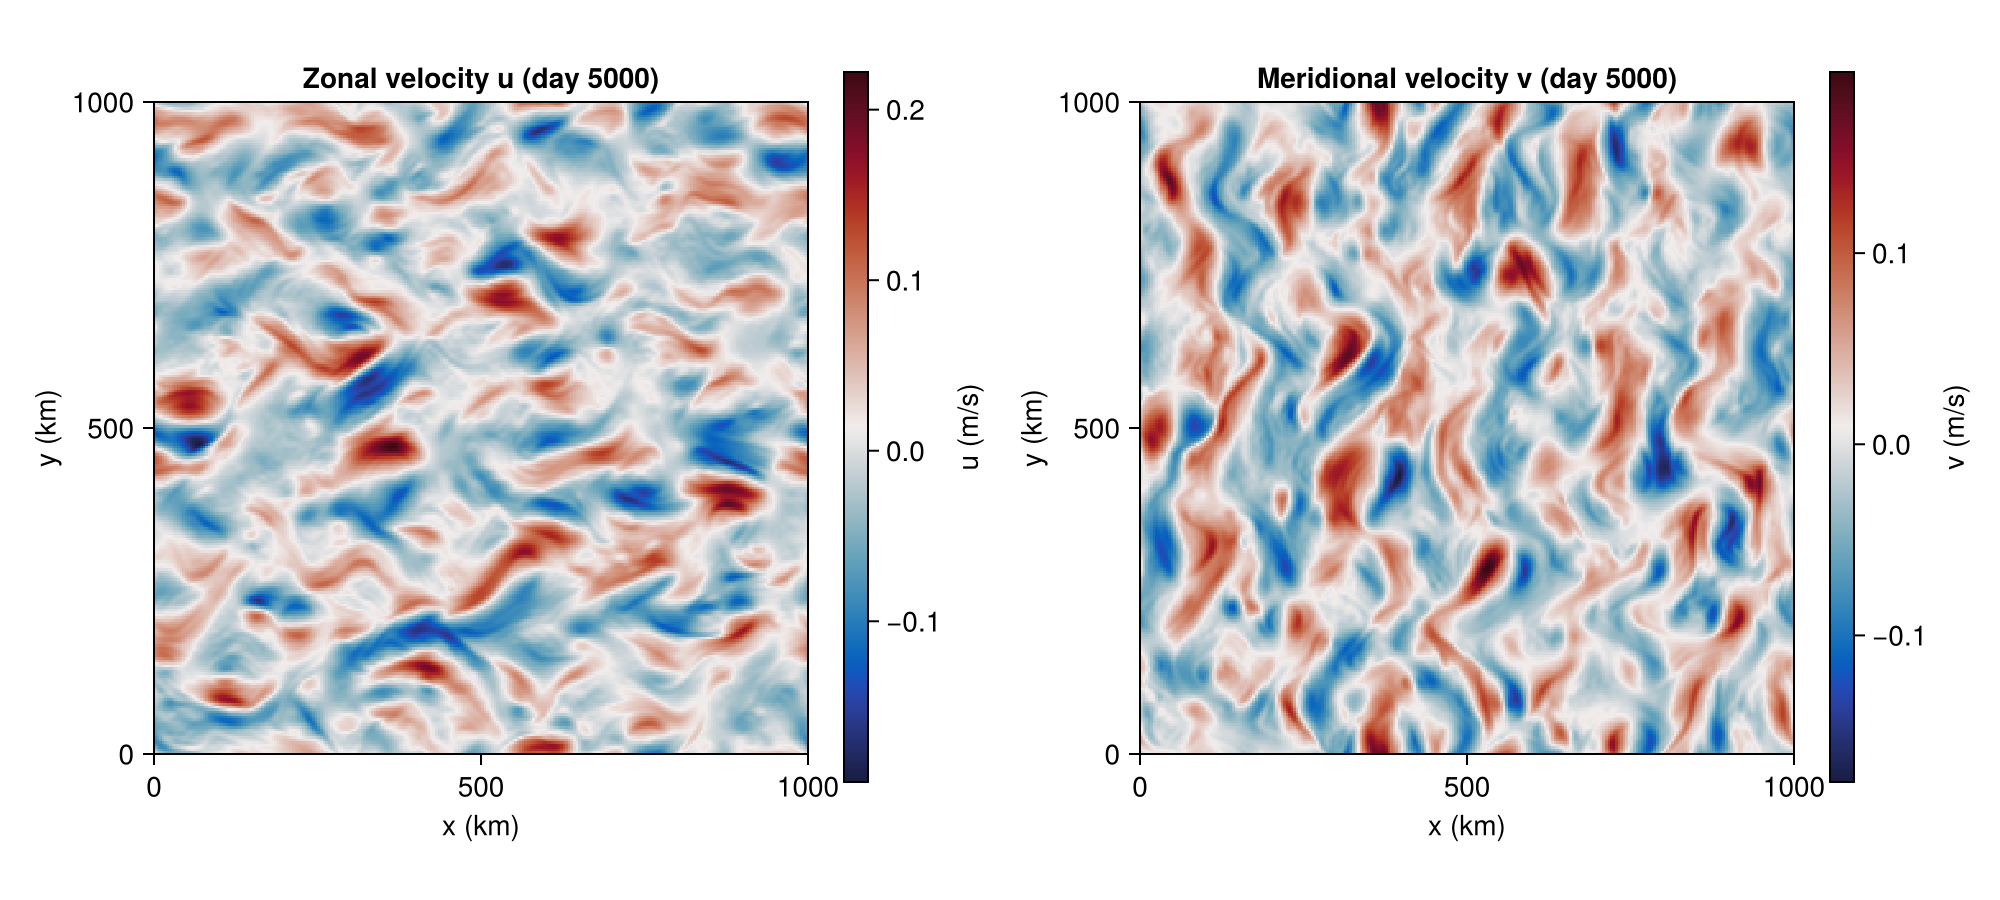

In [9]:
# Figure 1: Velocity field snapshot (u and v side by side)
fig1 = Figure(size=(1000, 450))

ax1 = Axis(fig1[1,1], title="Zonal velocity u (day $(Int(times[1]/86400)))",
    xlabel="x (km)", ylabel="y (km)", aspect=DataAspect())
hm1 = heatmap!(ax1, x_km, y_km, u_fields[1][1], colormap=:balance)
Colorbar(fig1[1,2], hm1, label="u (m/s)")

ax2 = Axis(fig1[1,3], title="Meridional velocity v (day $(Int(times[1]/86400)))",
    xlabel="x (km)", ylabel="y (km)", aspect=DataAspect())
hm2 = heatmap!(ax2, x_km, y_km, v_fields[1][1], colormap=:balance)
Colorbar(fig1[1,4], hm2, label="v (m/s)")

fig1

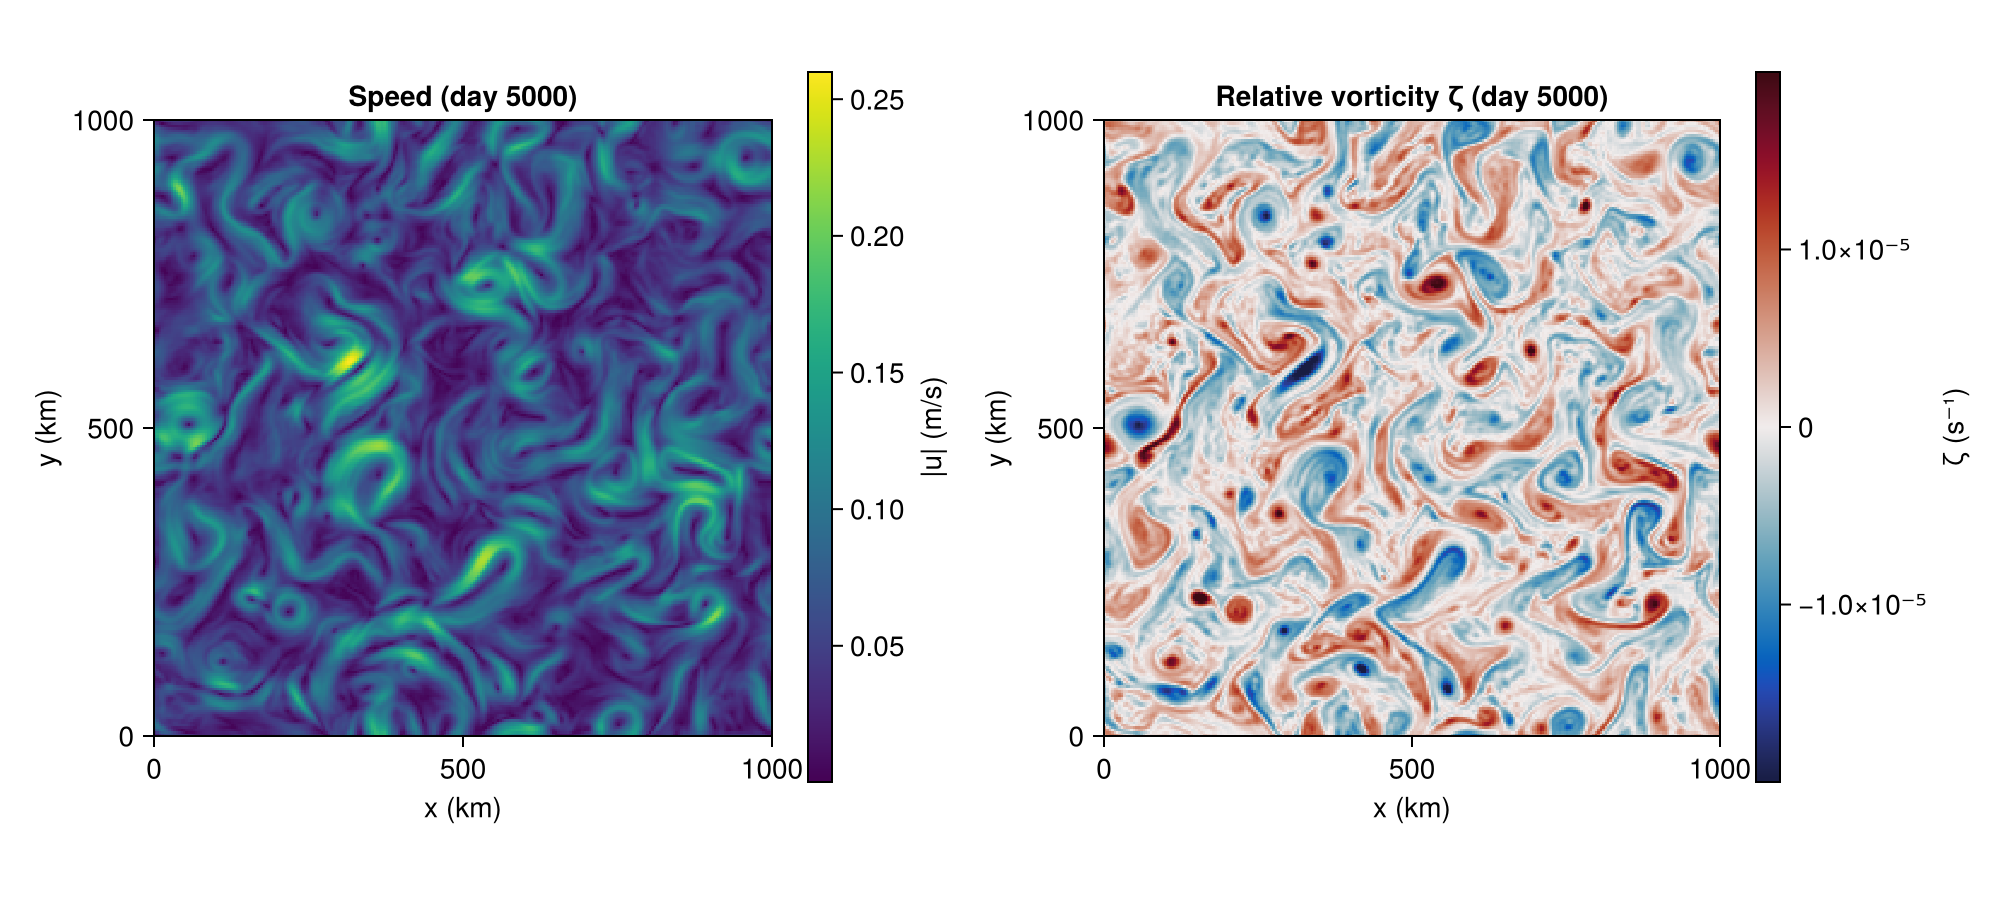

In [10]:
# Figure 2: Speed and relative vorticity
fig2 = Figure(size=(1000, 450))

# Speed
speed = sqrt.(u_fields[1][1].^2 .+ v_fields[1][1].^2)
ax3 = Axis(fig2[1,1], title="Speed (day $(Int(times[1]/86400)))",
    xlabel="x (km)", ylabel="y (km)", aspect=DataAspect())
hm3 = heatmap!(ax3, x_km, y_km, speed, colormap=:viridis)
Colorbar(fig2[1,2], hm3, label="|u| (m/s)")

# Relative vorticity: ζ = ∂v/∂x - ∂u/∂y (centered differences, periodic)
u_arr = u_fields[1][1]
v_arr = v_fields[1][1]
dvdx = (circshift(v_arr, (-1, 0)) .- circshift(v_arr, (1, 0))) ./ (2 * dx)
dudy = (circshift(u_arr, (0, -1)) .- circshift(u_arr, (0, 1))) ./ (2 * dy)
vort = dvdx .- dudy

ax4 = Axis(fig2[1,3], title="Relative vorticity ζ (day $(Int(times[1]/86400)))",
    xlabel="x (km)", ylabel="y (km)", aspect=DataAspect())
vlim = maximum(abs.(vort)) * 0.8
hm4 = heatmap!(ax4, x_km, y_km, vort, colormap=:balance, colorrange=(-vlim, vlim))
Colorbar(fig2[1,4], hm4, label="ζ (s⁻¹)")

fig2

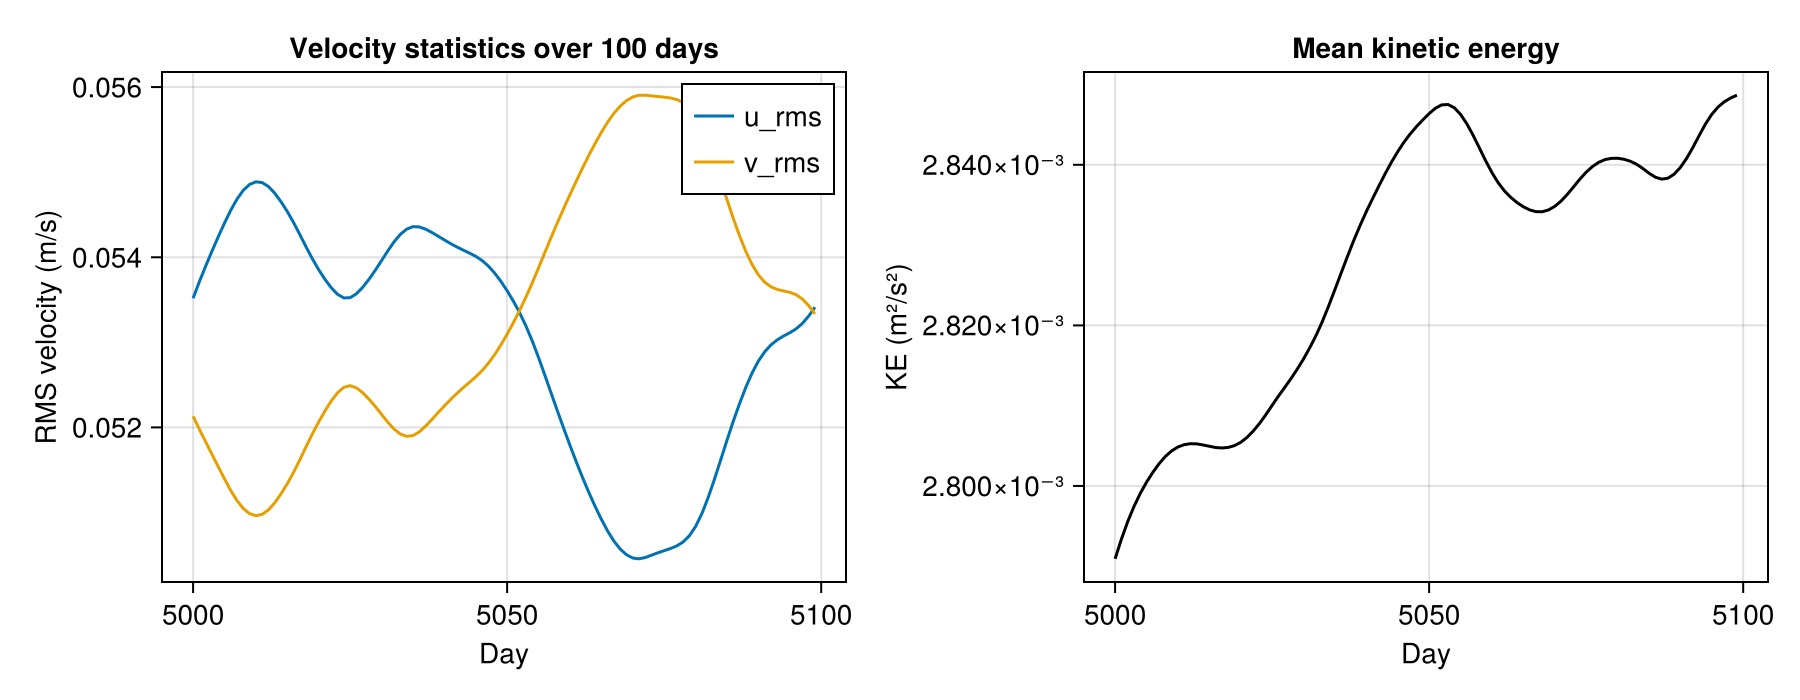

In [11]:
# Figure 3: Time series of velocity statistics over the 100 loaded snapshots
days = times ./ 86400
u_rms = [sqrt(sum(u_fields[k][1].^2) / length(u_fields[k][1])) for k in 1:length(u_fields)]
v_rms = [sqrt(sum(v_fields[k][1].^2) / length(v_fields[k][1])) for k in 1:length(v_fields)]
ke = [sum(u_fields[k][1].^2 .+ v_fields[k][1].^2) / (2 * length(u_fields[k][1])) for k in 1:length(u_fields)]

fig3 = Figure(size=(900, 350))
ax5 = Axis(fig3[1,1], xlabel="Day", ylabel="RMS velocity (m/s)",
    title="Velocity statistics over 100 days")
lines!(ax5, days, u_rms, label="u_rms")
lines!(ax5, days, v_rms, label="v_rms")
axislegend(ax5, position=:rt)

ax6 = Axis(fig3[1,2], xlabel="Day", ylabel="KE (m²/s²)",
    title="Mean kinetic energy")
lines!(ax6, days, ke, color=:black)

fig3